In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("titanic.csv")
print("原始数据形状：", df.shape)
print("缺失值统计：")
print(df.isnull().sum())
print("重复行数：", df.duplicated().sum())

df_drop_dup = df.drop_duplicates()
print("去重后行数：", df_drop_dup.shape[0])


df_del_na = df_drop_dup.dropna()
df_fill_const = df_drop_dup.copy()
df_fill_const["Cabin"] = df_fill_const["Cabin"].fillna("Unknown")
df_fill_const["Embarked"] = df_fill_const["Embarked"].fillna("S")
df_fill_stat = df_fill_const.copy()
df_fill_stat["Age"] = df_fill_stat["Age"].fillna(df_fill_stat["Age"].median())
df_interp = df_fill_stat.copy()
df_interp["Age"] = df_interp["Age"].interpolate(method="linear")
df_clean = df_interp.copy()
df_clean["Pclass"] = df_clean["Pclass"].astype("category")
df_clean["Survived"] = df_clean["Survived"].astype(bool)
df_clean["Name"] = df_clean["Name"].str.strip().str.lower()
df_clean = df_clean[df_clean["Fare"] < 300]

print("清洗完成数据信息：")
print(df_clean.info())
print("清洗后缺失值总量：", df_clean.isnull().sum().sum())
df_clean.to_csv("titanic_clean.csv", index=False)

原始数据形状： (891, 12)
缺失值统计：
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
重复行数： 0
去重后行数： 891
清洗完成数据信息：
<class 'pandas.core.frame.DataFrame'>
Index: 888 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  888 non-null    int64   
 1   Survived     888 non-null    bool    
 2   Pclass       888 non-null    category
 3   Name         888 non-null    object  
 4   Sex          888 non-null    object  
 5   Age          888 non-null    float64 
 6   SibSp        888 non-null    int64   
 7   Parch        888 non-null    int64   
 8   Ticket       888 non-null    object  
 9   Fare         888 non-null    float64 
 10  Cabin        888 non-null    object  
 11  Embarked     888 non-null    object  
dty

污染物描述性统计：
              pm2.5          DEWP          TEMP          PRES           Iws
count  43800.000000  43824.000000  43824.000000  43824.000000  43824.000000
mean      98.244966      1.817246     12.448521   1016.447654     23.889140
std       90.966982     14.433440     12.198613     10.268698     50.010635
min        0.000000    -40.000000    -19.000000    991.000000      0.450000
25%       30.000000    -10.000000      2.000000   1008.000000      1.790000
50%       73.000000      2.000000     14.000000   1016.000000      5.370000
75%      136.000000     15.000000     23.000000   1025.000000     21.910000
max      994.000000     28.000000     42.000000   1046.000000    585.600000


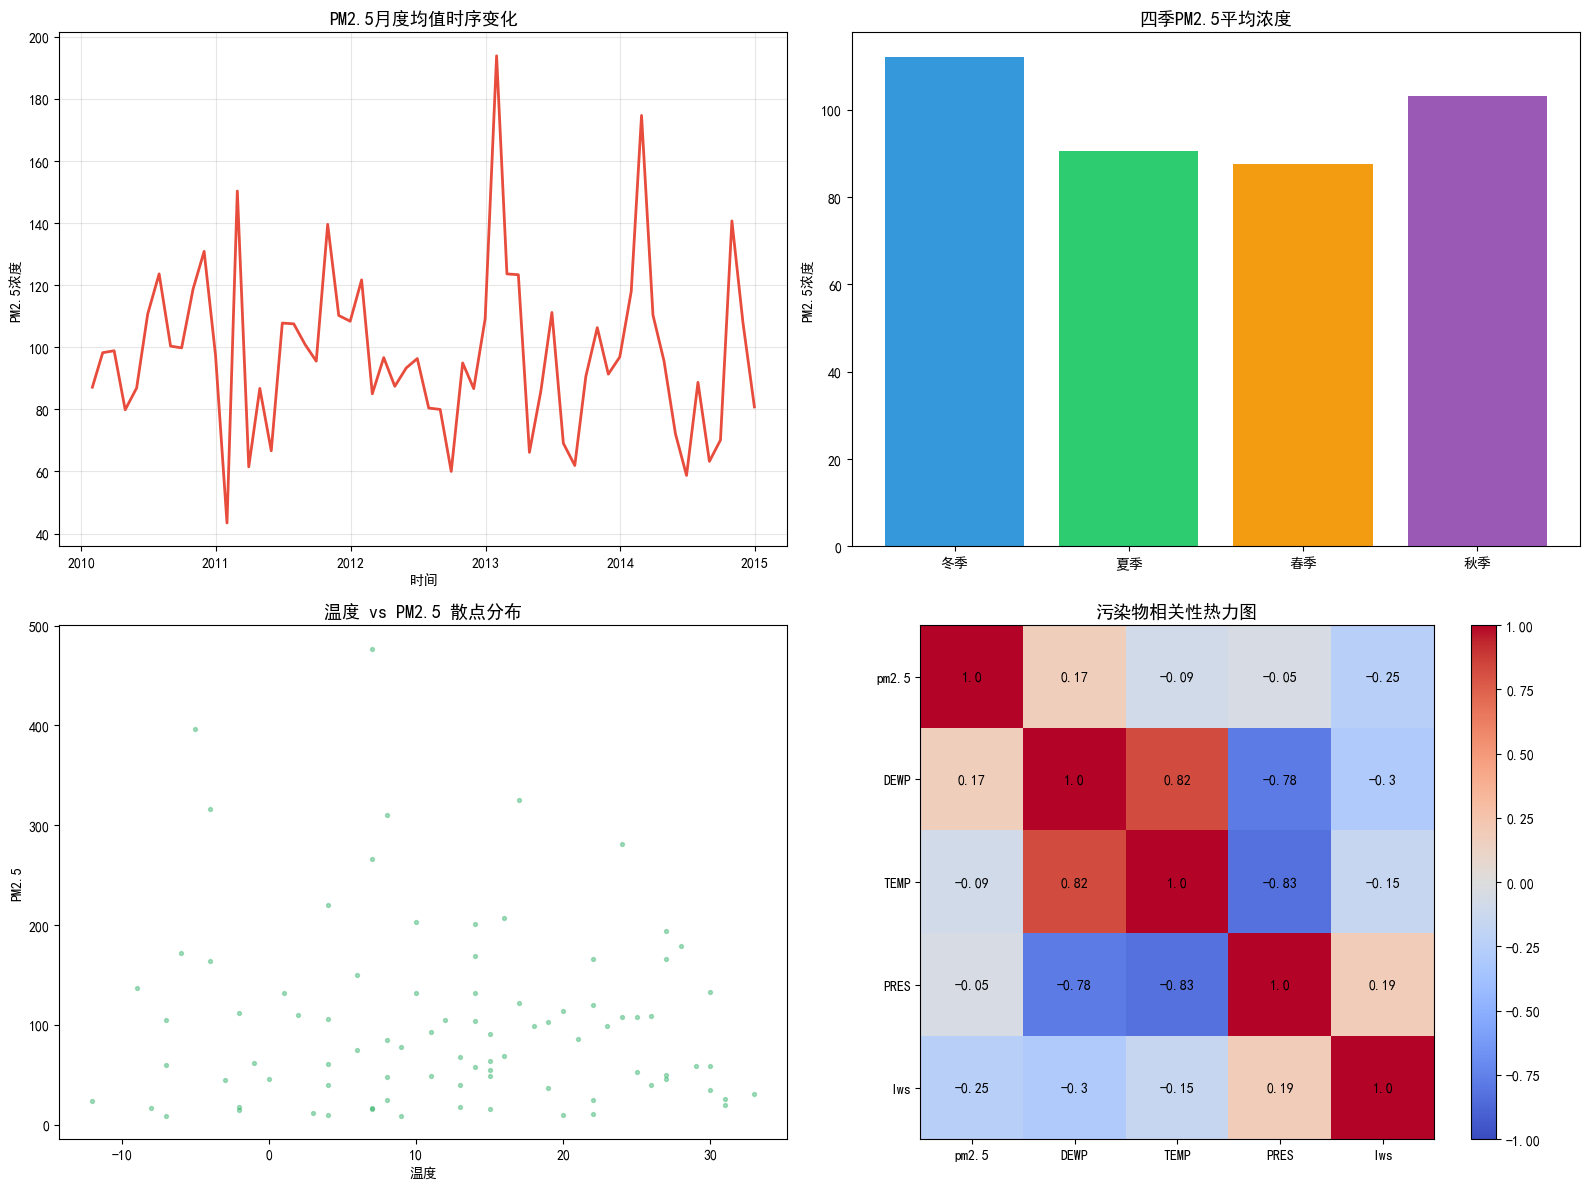


分季节PM2.5指标：
              mean         std    max  min
season                                    
冬季      112.112778  118.012029  994.0  2.0
夏季       90.644882   63.009028  466.0  1.0
春季       87.482292   73.033358  784.0  3.0
秋季      103.094093   98.101392  569.0  0.0


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False


url = "PRSA_data_2010.1.1-2014.12.31.csv"
air_df = pd.read_csv(url)


air_df["time"] = pd.to_datetime(air_df[["year", "month", "day", "hour"]])
air_df = air_df.set_index("time")
air_df = air_df.drop(["No", "year", "month", "day", "hour"], axis=1)

num_cols = air_df.select_dtypes(include=["number"]).columns
obj_cols = air_df.select_dtypes(exclude=["number"]).columns
air_df[num_cols] = air_df[num_cols].interpolate()

pollutants = ["pm2.5", "DEWP", "TEMP", "PRES", "Iws"]
print("污染物描述性统计：")
print(air_df[pollutants].describe())

corr_mat = air_df[pollutants].corr()


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


month_pm25 = air_df["pm2.5"].resample("ME").mean()
axes[0,0].plot(month_pm25.index, month_pm25.values, color="#e74c3c", linewidth=2)
axes[0,0].set_title("PM2.5月度均值时序变化", fontsize=13)
axes[0,0].set_xlabel("时间")
axes[0,0].set_ylabel("PM2.5浓度")
axes[0,0].grid(alpha=0.3)

season_map = {1:"冬季",2:"冬季",3:"春季",4:"春季",5:"春季",6:"夏季",7:"夏季",8:"夏季",9:"秋季",10:"秋季",11:"秋季",12:"冬季"}
air_df["season"] = air_df.index.month.map(season_map)
season_pm = air_df.groupby("season")["pm2.5"].mean()
axes[0,1].bar(season_pm.index, season_pm.values, color=["#3498db","#2ecc71","#f39c12","#9b59b6"])
axes[0,1].set_title("四季PM2.5平均浓度", fontsize=13)
axes[0,1].set_ylabel("PM2.5浓度")

axes[1,0].scatter(air_df["TEMP"][::500], air_df["pm2.5"][::500], alpha=0.4, color="#27ae60", s=8)
axes[1,0].set_title("温度 vs PM2.5 散点分布", fontsize=13)
axes[1,0].set_xlabel("温度")
axes[1,0].set_ylabel("PM2.5")

im = axes[1,1].imshow(corr_mat, cmap="coolwarm", vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(pollutants)))
axes[1,1].set_yticks(range(len(pollutants)))
axes[1,1].set_xticklabels(pollutants)
axes[1,1].set_yticklabels(pollutants)
axes[1,1].set_title("污染物相关性热力图", fontsize=13)

for i in range(len(pollutants)):
    for j in range(len(pollutants)):
        axes[1,1].text(j, i, round(corr_mat.iloc[i,j],2), ha="center", va="center", color="black")
plt.colorbar(im, ax=axes[1,1])

plt.tight_layout()
plt.savefig("air_quality_analysis.png", dpi=300)
plt.show()


season_analysis = air_df.groupby("season")["pm2.5"].agg(["mean","std","max","min"])
print("\n分季节PM2.5指标：")
print(season_analysis)